In [211]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split,cross_validate

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)

In [170]:
# Configurations

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x: .3f}")
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

RANDOM_STATE = 42
DATASET_PATH = "../data/Delivery_data.csv"
TARGET_COLUMN = "delayed"

In [171]:
df = pd.read_csv(DATASET_PATH)

In [172]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.990,delhivery,automobile parts,bike,same day,west,clear,297.000,46.960,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.721
1,250.990,xpressbees,cosmetics,ev van,express,central,cold,89.600,47.390,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.170
2,250.990,shadowfax,groceries,truck,two day,east,rainy,273.500,26.890,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.170
3,250.990,dhl,electronics,ev van,same day,east,cold,269.700,12.690,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.570
4,250.990,dhl,clothing,van,two day,north,foggy,256.700,37.020,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.560


In [173]:
df.columns

Index(['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
       'delivery_mode', 'region', 'weather_condition', 'distance_km',
       'package_weight_kg', 'delivery_time_hours', 'expected_time_hours',
       'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost'],
      dtype='str')

In [174]:
df.shape

(25000, 15)

In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  str    
 2   package_type         25000 non-null  str    
 3   vehicle_type         25000 non-null  str    
 4   delivery_mode        25000 non-null  str    
 5   region               25000 non-null  str    
 6   weather_condition    25000 non-null  str    
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  str    
 10  expected_time_hours  25000 non-null  str    
 11  delayed              25000 non-null  str    
 12  delivery_status      25000 non-null  str    
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), str(10)
memory usage: 

In [176]:
df.isna().sum()

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

In [177]:
df["delayed"].value_counts()

delayed
no     18331
yes     6669
Name: count, dtype: int64

In [178]:
df["delivery_status"].value_counts()

delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

In [179]:
df["delivery_time_hours"].value_counts().head(20)

delivery_time_hours
1970-01-01 00:00:00.000000006    3118
1970-01-01 00:00:00.000000005    3011
1970-01-01 00:00:00.000000007    2921
1970-01-01 00:00:00.000000004    2571
1970-01-01 00:00:00.000000008    2386
1970-01-01 00:00:00.000000003    2352
1970-01-01 00:00:00.000000009    1875
1970-01-01 00:00:00.000000002    1668
1970-01-01 00:00:00.000000010    1371
1970-01-01 00:00:00.000000011    1039
1970-01-01 00:00:00.000000001     963
1970-01-01 00:00:00.000000012     649
1970-01-01 00:00:00.000000013     371
1970-01-01 00:00:00.000000000     255
1970-01-01 00:00:00.000000014     247
1970-01-01 00:00:00.000000015     116
1970-01-01 00:00:00.000000016      51
1970-01-01 00:00:00.000000017      26
1970-01-01 00:00:00.000000018       7
1970-01-01 00:00:00.000000019       3
Name: count, dtype: int64

In [180]:
df["expected_time_hours"].value_counts().head(20)

expected_time_hours
1970-01-01 00:00:00.000000016    6302
1970-01-01 00:00:00.000000008    6287
1970-01-01 00:00:00.000000024    6186
1970-01-01 00:00:00.000000005    1080
1970-01-01 00:00:00.000000007    1051
1970-01-01 00:00:00.000000004    1037
1970-01-01 00:00:00.000000003    1029
1970-01-01 00:00:00.000000002    1015
1970-01-01 00:00:00.000000006    1013
Name: count, dtype: int64

In [181]:
df["delivery_time_hours"] = pd.to_datetime(df["delivery_time_hours"]).dt.nanosecond
df["expected_time_hours"] = pd.to_datetime(df["expected_time_hours"]).dt.nanosecond

In [182]:
df[["delivery_time_hours", "expected_time_hours", "delayed"]].head(20)

,delivery_time_hours,expected_time_hours,delayed
0,8,8,no
1,2,3,no
2,10,16,no
3,6,8,no
4,9,16,no
5,4,2,yes
6,6,8,no
7,4,8,no
8,5,8,no
9,3,8,no


In [183]:
df = df.drop(
    columns=[
        "delivery_id",
        "delivery_status",
        "expected_time_hours",
        "delivery_time_hours",
        "delivery_rating",
    ]
)

In [184]:
df

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.000,46.960,no,1632.721
1,xpressbees,cosmetics,ev van,express,central,cold,89.600,47.390,no,640.170
2,shadowfax,groceries,truck,two day,east,rainy,273.500,26.890,no,1448.170
3,dhl,electronics,ev van,same day,east,cold,269.700,12.690,no,1486.570
4,dhl,clothing,van,two day,north,foggy,256.700,37.020,no,1394.560
...,...,...,...,...,...,...,...,...,...,...
24995,dhl,furniture,scooter,two day,east,foggy,80.700,3.650,no,414.450
24996,ecom express,automobile parts,ev van,standard,west,clear,172.900,21.420,no,928.760
24997,ekart,clothing,scooter,same day,east,rainy,168.400,4.850,yes,956.550
24998,shadowfax,documents,ev van,standard,west,stormy,37.200,8.040,no,210.120


In [185]:
df[TARGET_COLUMN] = df[TARGET_COLUMN].map({"no": 0, "yes": 1})

X = df.drop(columns=["delayed"])
y = df[TARGET_COLUMN]

In [186]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COLUMN]

print("Target Column:", TARGET_COLUMN)
print("Numerical Column", num_cols)
print("Categorical Column", cat_cols)

Target Column: delayed
Numerical Column ['distance_km', 'package_weight_kg', 'delayed', 'delivery_cost']
Categorical Column ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']


In [187]:
for col in df.columns:
    print(df[col].value_counts().head(10))

delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64
weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name

In [188]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (25000, 10)


In [189]:
df.describe()

,distance_km,package_weight_kg,delayed,delivery_cost
count,25000.000,25000.000,25000.000,25000.000
mean,150.390,25.146,0.267,864.945
std,86.410,14.369,0.442,435.713
min,3.600,0.670,0.000,95.667
25%,75.900,12.680,0.000,490.800
50%,151.000,25.145,0.000,867.535
75%,224.900,37.660,1.000,1237.910
max,297.100,49.520,1.000,1632.721


<Axes: xlabel='delayed', ylabel='count'>

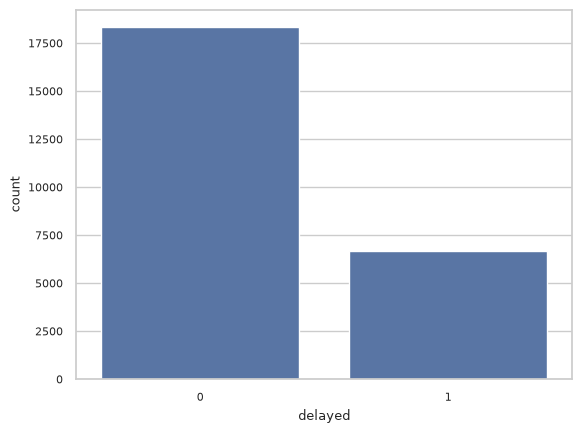

In [190]:
sns.countplot(x=y)

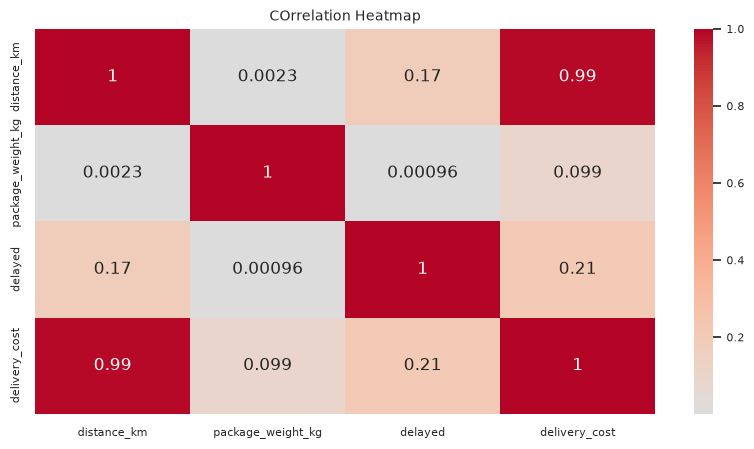

In [191]:
plt.figure(figsize=(10, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)

plt.title("COrrelation Heatmap")
plt.show()

In [192]:
corr_with_target = df[num_cols].corr()[TARGET_COLUMN].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
delayed              1.000
delivery_cost        0.210
distance_km          0.174
package_weight_kg    0.001
Name: delayed, dtype: float64


In [193]:
X.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.000,46.960,1632.721
1,xpressbees,cosmetics,ev van,express,central,cold,89.600,47.390,640.170
2,shadowfax,groceries,truck,two day,east,rainy,273.500,26.890,1448.170
3,dhl,electronics,ev van,same day,east,cold,269.700,12.690,1486.570
4,dhl,clothing,van,two day,north,foggy,256.700,37.020,1394.560


In [194]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: delayed, dtype: int64

In [195]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [196]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (20000, 9)
Test Shape: (5000, 9)


In [197]:
# Preprocessing Pipeline

numerical_features = X_train.select_dtypes(include=(np.number)).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=(np.number)).columns.tolist()
print(numerical_features)
print(categorical_features)

numerical_transformer = Pipeline(
    steps=[
        ("scalar", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

['distance_km', 'package_weight_kg', 'delivery_cost']
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']


In [ ]:
baseline_pipeline = Pipeline(
    steps=[("preprocess", preprocess), ("model", LogisticRegression())]
)

In [ ]:
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['delivery_partner','package_type','vehicle_type',...,'distance_km', 'package_weight_kg','delivery_cost']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [200]:
training_baseline_pred = baseline_pipeline.predict(X_train)
test_baseline_pred = baseline_pipeline.predict(X_test)

In [ ]:
train_baseline_accuracy = accuracy_score(y_train, training_baseline_pred)
train_baseline_precision = precision_score(y_train, training_baseline_pred)
train_baseline_recall = recall_score(y_train, training_baseline_pred)
train_baseline_cf = confusion_matrix(y_train, training_baseline_pred)


print("\n=== TRAIN BASELINE METRICS (Logistic Regression) ===")
print(f"Accuracy:{train_baseline_accuracy:.3f}")
print(f"Precision:{train_baseline_precision:.3f}")
print(f"Recall:{train_baseline_recall:.3f}")
print(f"Confustion Matrix:\n{train_baseline_cf}")


test_baseline_accuracy = accuracy_score(y_test, test_baseline_pred)
test_baseline_precision = precision_score(y_test, test_baseline_pred)
test_baseline_recall = recall_score(y_test, test_baseline_pred)
test_baseline_cf = confusion_matrix(y_test, test_baseline_pred)


print("\n=== TEST BASELINE METRICS (Logistic Regression) ===")
print(f"Accuracy:{test_baseline_accuracy:.3f}")
print(f"Precision:{test_baseline_precision:.3f}")
print(f"Recall:{test_baseline_recall:.3f}")
print(f"Confustion Matrix:\n{test_baseline_cf}")


=== TRAIN BASELINE METRICS (Logistic Regression) ===
Accuracy:0.898
Precision:0.810
Recall:0.809
Confustion Matrix:
[[13636  1018]
 [ 1020  4326]]

=== TEST BASELINE METRICS (Logistic Regression) ===
Accuracy:0.904
Precision:0.816
Recall:0.825
Confustion Matrix:
[[3430  247]
 [ 231 1092]]


In [ ]:
# Model Selection and optimization

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import KFold

In [206]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 5.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.1/305.1 MB 5.6 MB/s eta 0:00:00m eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [207]:
from xgboost import XGBClassifier

In [208]:
models = {
    "LogisticRegression": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE),
    "SupportVectorMachine": SVC(),
    "xgboost": XGBClassifier(
        n_estimator=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE
    ),
}

In [209]:
k=5
cv=KFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)

In [213]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall'
}

In [218]:
rows=[]
for name,model in models.items():
    pipe=Pipeline(
        steps=[
            ('preprocess',preprocess),
            ('model',model)
        ]
    )
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    rows.append({
        "model":name,
        "cv_accuracy":scores["test_accuracy"].mean(),
        "cv_precision":scores["test_precision"].mean(),
        "cv_recall":scores["test_recall"].mean()
    })
cv_results = pd.DataFrame(rows).sort_values("cv_accuracy")
print("=== CV Model Comparsion ===")
print(cv_results)


=== CV Model Comparsion ===
                  model  cv_accuracy  cv_precision  cv_recall
1          DecisionTree        0.870         0.757      0.757
2          RandomForest        0.891         0.792      0.806
3  SupportVectorMachine        0.896         0.798      0.817
4               xgboost        0.897         0.799      0.821
0    LogisticRegression        0.898         0.809      0.808


/run/media/biplob/e1a9a613-7e49-4b9e-81ed-a1c7ad2b4cae/biplob/ml_practice/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:10:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/run/media/biplob/e1a9a613-7e49-4b9e-81ed-a1c7ad2b4cae/biplob/ml_practice/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:10:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/run/media/biplob/e1a9a613-7e49-4b9e-81ed-a1c7ad2b4cae/biplob/ml_practice/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:10:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/run/media/biplob/e1a9a613-7e49-4b9e-81ed-a1c7ad2b4cae/biplob/ml_practice/venv/lib/python3.14/site-packages/x